# House Price Prediction Using Machine Learning

### Minor Project

**Name:** Ashmita Thiyam  
**Domain:** Data Science


**Objective:** To predict house prices using machine learning regression algorithms.

**Algorithms Used:**
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

## I. DATASET COLLECTION & LOADING


In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("AmesHousing.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (2930, 82)


## II. DATASET UNDERSTANDING

In [96]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [98]:
df.isnull().sum().sort_values(ascending=False).head(15)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
dtype: int64

In [99]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [100]:
df["SalePrice"].isnull().sum()

np.int64(0)

## III.EDA

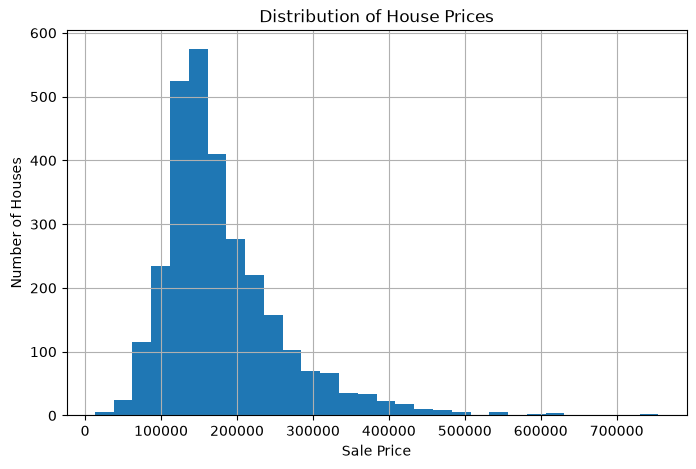

In [101]:
df["SalePrice"].hist(bins=30, figsize=(8, 5))

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

In [102]:
import matplotlib.pyplot as plt

In [103]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

correlation.head(10)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

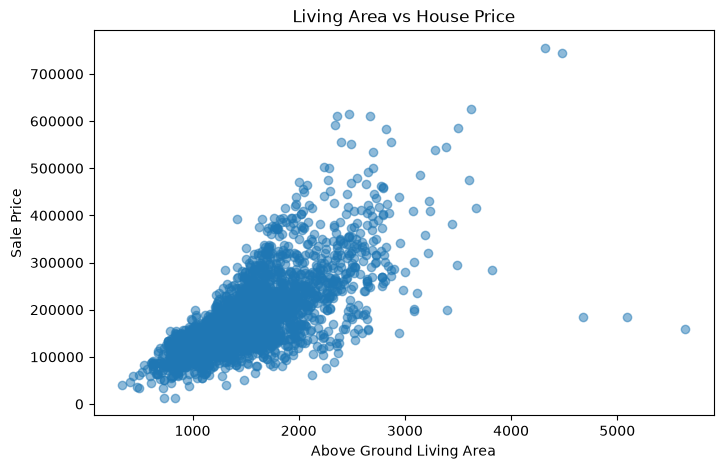

In [104]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)

plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs House Price")

plt.show()

In [105]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## IV. DATA CLEANING & HANDLING MISSING VALUES

In [106]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64

In [107]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 15749


In [108]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64

In [109]:

none_columns = [
    "Pool QC",
    "Misc Feature",
    "Alley",
    "Fence",
    "Mas Vnr Type",
    "Fireplace Qu",
    "Garage Qual",
    "Garage Cond",
    "Garage Finish",
    "Garage Type",
    "Bsmt Exposure",
    "BsmtFin Type 2",
    "Bsmt Qual",
    "Bsmt Cond",
    "BsmtFin Type 1"
]

df[none_columns] = df[none_columns].fillna("None")

print("Categorical missing values handled.")

Categorical missing values handled.


In [110]:

zero_columns = [
    "Mas Vnr Area",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Total Bsmt SF",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Garage Area",
    "Garage Cars",
    "Bsmt Unf SF"
]

df[zero_columns] = df[zero_columns].fillna(0)

print("Numerical missing values handled.")

Numerical missing values handled.


In [111]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

print("Lot Frontage missing values handled.")


Lot Frontage missing values handled.


In [112]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print("Electrical missing value handled.")

Electrical missing value handled.


In [113]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 159


In [114]:
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [115]:
df.to_csv("cleaned_AmesHousing.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [116]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())

Rows: 2930
Columns: 82
Missing values: 0


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Libraries loaded!")

Libraries loaded!


In [118]:
df = pd.read_csv("cleaned_AmesHousing.csv")

print("Cleaned dataset loaded!")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Cleaned dataset loaded!
Shape: (2930, 82)
Missing values: 15066


In [119]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

print("\nMissing values by column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Current folder:
/Users/ashmitathiyam/Desktop/house_pred

Files in current folder:
['model_comparison.csv', 'House_Price_Prediction_Project_Report.doc', 'screenshots', '.DS_Store', 'requirements.txt', 'house_price_model.pkl', 'README.md', '.gitignore', '.venv', 'cleaned_AmesHousing.csv', 'app.py', 'AmesHousing.csv', '.git', 'House_Price_Prediction.ipynb']

Missing values by column:
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Garage Finish     159
Garage Cond       159
Garage Qual       159
Garage Type       157
dtype: int64


In [120]:

df.to_csv("cleaned_AmesHousing.csv", index=False)

print("Cleaned dataset saved!")
print("Remaining missing values:", df.isnull().sum().sum())

Cleaned dataset saved!
Remaining missing values: 15066


In [121]:
df.isnull().sum().sum()

np.int64(15066)

## V. FEATURE ENGINEERING

In [122]:
df["TotalSF"] = (
    df["Total Bsmt SF"] +
    df["1st Flr SF"] +
    df["2nd Flr SF"]
)

print("TotalSF created!")

TotalSF created!


In [123]:
df["TotalBathrooms"] = (
    df["Full Bath"] +
    0.5 * df["Half Bath"] +
    df["Bsmt Full Bath"] +
    0.5 * df["Bsmt Half Bath"]
)

print("TotalBathrooms created!")

TotalBathrooms created!


In [124]:
df["TotalPorchSF"] = (
    df["Open Porch SF"] +
    df["Enclosed Porch"] +
    df["3Ssn Porch"] +
    df["Screen Porch"] +
    df["Wood Deck SF"]
)

print("TotalPorchSF created!")

TotalPorchSF created!


In [125]:
df[["TotalSF", "TotalBathrooms", "TotalPorchSF", "SalePrice"]].head()

,TotalSF,TotalBathrooms,TotalPorchSF,SalePrice
0,2736.0,2.0,272,215000
1,1778.0,1.0,260,105000
2,2658.0,1.5,429,172000
3,4220.0,3.5,0,244000
4,2557.0,2.5,246,189900


## VI. DATA PREPROCESSING

In [126]:
# Separating input features (X) and target variable (y)

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2930, 84)
Target: (2930,)


In [127]:

id_columns = ["Order", "PID"]
X = X.drop(columns=id_columns)
print("Features after removing IDs:", X.shape)

Features after removing IDs: (2930, 82)


In [128]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 39
Categorical features: 43


/var/folders/hk/6v3l523d2dngjr9l12_2s7tr0000gn/T/ipykernel_1461/346851995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [129]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 39
Categorical features: 43


/var/folders/hk/6v3l523d2dngjr9l12_2s7tr0000gn/T/ipykernel_1461/2917816729.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [130]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


## VII. MODEL DEVELOPMENT

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2344
Testing samples: 586


In [132]:
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

print("Three models created successfully!")

Three models created successfully!


In [133]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)

print("Training Decision Tree...")
tree_model.fit(X_train, y_train)

print("Training Random Forest...")
forest_model.fit(X_train, y_train)

print("All models trained successfully!")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
All models trained successfully!


## VIII. MODEL EVALUATION & COMPARISON

In [134]:
# Making predictions on the test data

linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [135]:
#evaluation metrics

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }


results = []

results.append(evaluate_model("Linear Regression", y_test, linear_pred))
results.append(evaluate_model("Decision Tree", y_test, tree_pred))
results.append(evaluate_model("Random Forest", y_test, forest_pred))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,17905.057454,9.099981e+08,30166.174509,0.886499
1,Decision Tree,26142.073379,1.921409e+09,43833.882194,0.760350
2,Random Forest,15343.698464,6.309905e+08,25119.523995,0.921299


In [136]:
results_df.to_csv("model_comparison.csv", index=False)

print("Model comparison saved!")

Model comparison saved!


## IX. MODEL VISUALIZATION & ANALYSIS

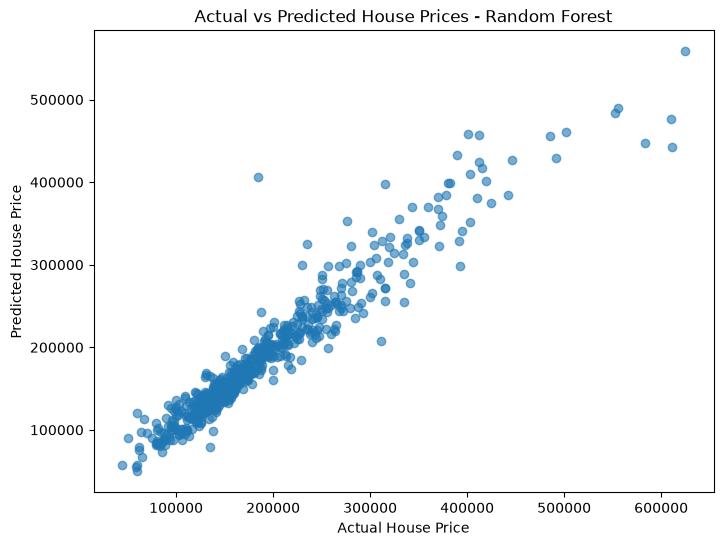

In [137]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, forest_pred, alpha=0.6)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices - Random Forest")

plt.show()

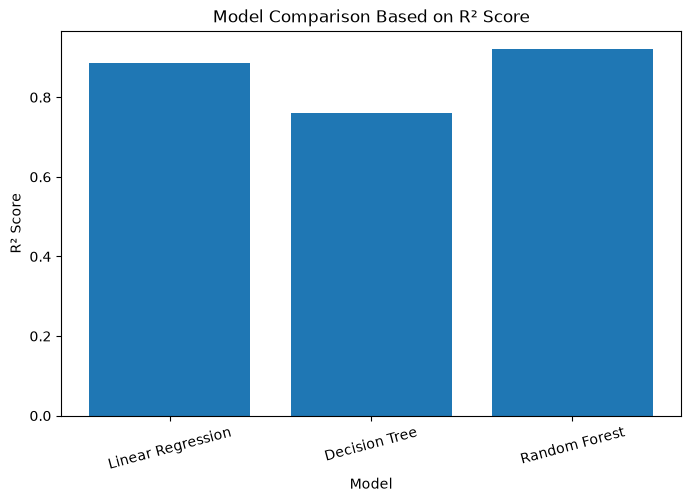

In [138]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison Based on R² Score")

plt.xticks(rotation=15)
plt.show()

In [139]:
import joblib

In [140]:
#best performing model

joblib.dump(forest_model, "house_price_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


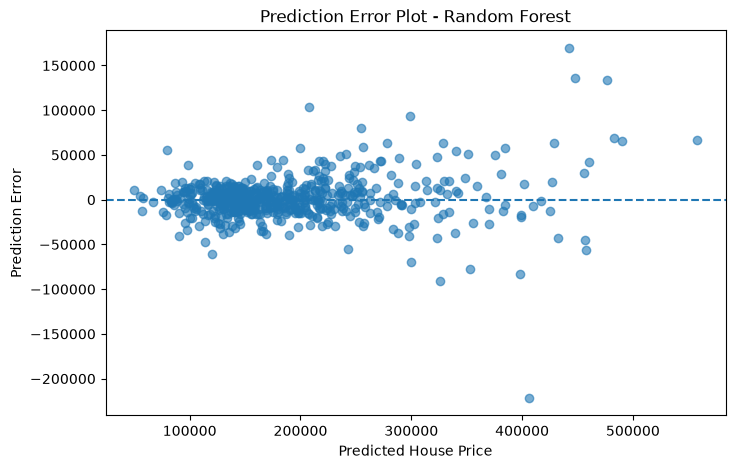

In [141]:
# Prediction Error / Residual Plot

prediction_errors = y_test - forest_pred

plt.figure(figsize=(8, 5))

plt.scatter(forest_pred, prediction_errors, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Plot - Random Forest")

plt.show()

In [142]:
# Feature Importance Analysis

rf_model = forest_model.named_steps["model"]

encoded_features = forest_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

feature_importance_df

,Feature,Importance
3,num__Overall Qual,0.473445
36,num__TotalSF,0.308651
5,num__Year Built,0.023008
13,num__2nd Flr SF,0.018327
15,num__Gr Liv Area,0.011620
37,num__TotalBathrooms,0.011290
2,num__Lot Area,0.011149
6,num__Year Remod/Add,0.009030
26,num__Garage Area,0.008866
8,num__BsmtFin SF 1,0.008578


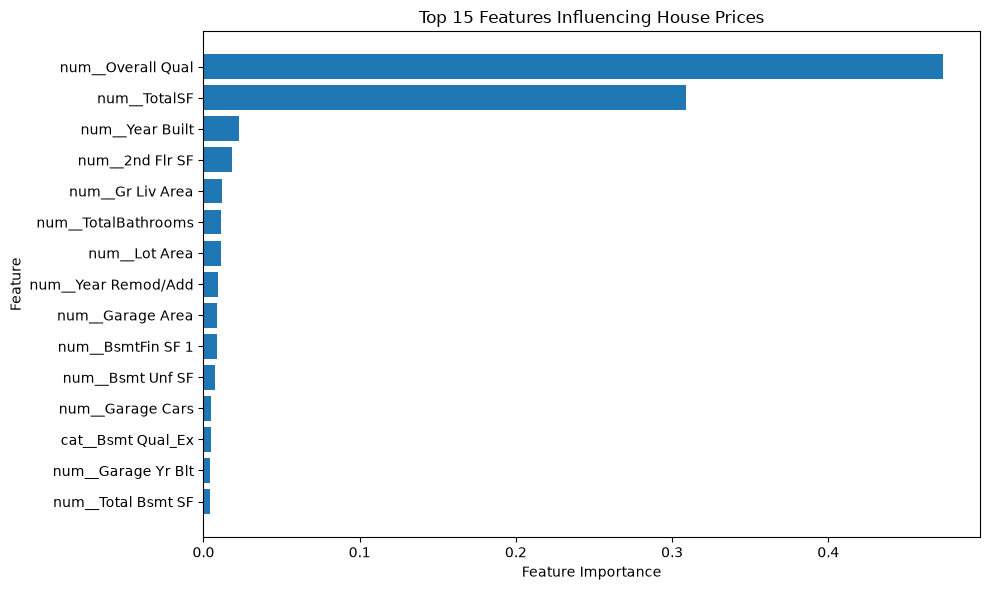

In [143]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"][::-1],
    feature_importance_df["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing House Prices")

plt.tight_layout()
plt.show()

## X. HOUSE PRICE PREDICTION

In [144]:
# House Price Prediction

# Selecting a house from the test set
sample_house = X_test.iloc[[0]]

# Predicting the price
predicted_price = forest_model.predict(sample_house)[0]

# Getting the actual price
actual_price = y_test.iloc[0]

# results
print("Sample house selected.")
print(f"Actual House Price:    ${actual_price:,.2f}")
print(f"Predicted House Price: ${predicted_price:,.2f}")
print(f"Prediction Difference: ${abs(actual_price - predicted_price):,.2f}")

Sample house selected.
Actual House Price:    $161,000.00
Predicted House Price: $175,197.02
Prediction Difference: $14,197.02


## XI. CONCLUSION

## XI. Conclusion

This project developed a machine learning-based system for predicting house prices using the Ames Housing dataset, obtained from Kaggle. The dataset contains various property-related features like location, size, quality, construction details, and other characteristics that influence house prices.

Three regression algorithms were implemented and compared: Linear Regression, Decision Tree Regression, and Random Forest Regression. The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Among the evaluated models, Random Forest Regression achieved the best performance, with an R² score of **0.9231**, an MAE of approximately **$15,260**, and an RMSE of approximately **$24,825**.
